# Prédiction des mouvements de trading avec un modèle Transformer
Dans ce projet, nous allons développer et tester un modèle de réseau de neurones basé sur l'architecture Transformer pour prédire, heure par heure, les actions (acheter, vendre, attendre) sur les actions du CAC40. Nous identifierons également les actions les plus prometteuses pour l'investissement.


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import random
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

In [85]:
# Chargement des données
data = pd.read_csv('cac40_clean_format.csv', parse_dates=['Datetime'])
print(data.head())
print(data.info())

                   Datetime  Price  Ticker       Value
0 2023-03-13 08:00:00+00:00  Close   AC.PA   29.910000
1 2023-03-13 08:00:00+00:00  Close  ACA.PA   10.668000
2 2023-03-13 08:00:00+00:00  Close   AI.PA  133.545456
3 2023-03-13 08:00:00+00:00  Close  AIR.PA  119.599998
4 2023-03-13 08:00:00+00:00  Close   BN.PA   54.230000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913740 entries, 0 to 913739
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   Datetime  913740 non-null  datetime64[ns, UTC]
 1   Price     913740 non-null  object             
 2   Ticker    913740 non-null  object             
 3   Value     913740 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 27.9+ MB
None


Ici, on :

- Convertit la colonne Datetime en index ou en features temporelles exploitables.
- Nettoye et normalise les données.
- Crée des indicateurs techniques ou des features supplémentaires (par exemple, moyennes mobiles, volatilité, etc.).


In [86]:
# Mise en forme : on se sert de la colonne Datetime comme index
data.set_index('Datetime', inplace=True)

# Filtrer sur 'Close'
data = data[data['Price'] == 'Close']

# Supprimer la colonne 'Price'
data.drop(columns=['Price'], inplace=True)

# Tri + suppression de doublons
data.sort_values(by=['Ticker', data.index.name], inplace=True)
data.reset_index(inplace=True)
data.drop_duplicates(subset=['Ticker', 'Datetime'], inplace=True)

# Remettre Datetime comme index
data.set_index('Datetime', inplace=True)

# Calcul de la variation
data['Variation'] = data.groupby('Ticker')['Value'].pct_change()

# Remplacer les valeurs infinies par NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Supprimer les lignes où 'Variation' ou 'Value' sont NaN
data.dropna(subset=['Variation', 'Value'], inplace=True)

# (Optionnel) Filtrer les lignes avec Value <= 0
data = data[data['Value'] > 0]

In [87]:
# (Optionnel) Normalisation des features pour Value et Variation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Value', 'Variation']] = scaler.fit_transform(data[['Value', 'Variation']])

print(data.describe())

              Value     Variation
count  1.827080e+05  1.827080e+05
mean  -1.742251e-17 -1.042239e-17
std    1.000003e+00  1.000003e+00
min   -4.554764e-01 -1.256386e+02
25%   -3.750539e-01 -3.682118e-01
50%   -2.863729e-01 -5.568254e-03
75%   -3.142269e-02  3.774852e-01
max    8.055120e+00  2.325385e+01


In [88]:
# Sélection d'un ticker, ex. 'AC.PA'
ticker_data = data[data['Ticker'] == 'AC.PA'].drop(columns=['Ticker'])
# S'assurer que ticker_data.index est unique
ticker_data = ticker_data[~ticker_data.index.duplicated(keep='first')]

Pour exploiter le modèle Transformer, on prépare les données sous forme de séquences temporelles (fenêtrage). On crée également une fonction qui discrétise l'information en une étiquette scalaire :

In [89]:
# Fonction de discrétisation
def discretize_label(row):
    if row['Variation'] > 0.01:
        return 0  # Acheter
    elif row['Variation'] < -0.01:
        return 1  # Vendre
    else:
        return 2  # Attendre

# Création des séquences temporelles
def create_sequences(df, window_size):
    sequences = []
    labels = []
    for i in range(len(df) - window_size):
        seq = df.iloc[i:i+window_size].values
        label = discretize_label(df.iloc[i+window_size])
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Sélection d'un ticker
ticker_data = data[data['Ticker'] == 'AC.PA'].drop(columns=['Ticker', 'Price'])
window_size = 10
X, y = create_sequences(ticker_data, window_size=window_size)

# Conversion en tenseurs
X_batch = torch.tensor(X, dtype=torch.float32).transpose(0, 1)  # [sequence_length, batch_size, input_dim]
y_batch = torch.tensor(y, dtype=torch.long)

KeyError: "['Price'] not found in axis"

In [ ]:
# Vérification
print("Any NaN in X_batch ?", torch.isnan(X_batch).any().item())
print("Any Inf in X_batch ?", torch.isinf(X_batch).any().item())
print("X_batch shape:", X_batch.shape)
print("X_batch min:", X_batch.min().item(), "X_batch max:", X_batch.max().item())

label_counts = pd.Series(y).value_counts().sort_index()
print("Répartition des labels (Pandas) :")
print(label_counts)

Any NaN in X_batch ? False
Any Inf in X_batch ? False
X_batch shape: torch.Size([10, 21898, 2])
X_batch min: -0.24602191150188446 X_batch max: 4.142420768737793
Répartition des labels (Pandas) :
0     1852
1    19633
2      413
Name: count, dtype: int64


On définit une architecture Transformer adaptée aux séries temporelles. Ici on commence par un modèle simple avec uniquement l'encodeur :


On définit la boucle d'entraînement, la fonction de perte, et l'optimiseur :

In [ ]:
# Définition du modèle Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, num_classes):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(model_dim, num_classes)
    
    def forward(self, src):
        src = self.input_projection(src)
        output = self.transformer_encoder(src)
        output = self.classifier(output[-1])
        return output

input_dim = X.shape[2]  # nombre de features par timestep
model_dim = 64
num_heads = 4
num_layers = 2
num_classes = 3  # Acheter, Vendre, Attendre
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, num_classes)

# Boucle d'entraînement
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_batch)
    loss = criterion(outputs, y_batch)
    
    if torch.isnan(loss):
        print("Loss is NaN! Arrêt de l'entraînement.")
        break
    
    loss.backward()
    # Appliquer le gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")


c:\Users\thiba\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/10, Loss: 1.3568
Epoch 2/10, Loss: 0.3955
Epoch 3/10, Loss: 0.3838
Epoch 4/10, Loss: 0.3812
Epoch 5/10, Loss: 0.3826
Epoch 6/10, Loss: 0.3763
Epoch 7/10, Loss: 0.3751
Epoch 8/10, Loss: 0.3756
Epoch 9/10, Loss: 0.3746
Epoch 10/10, Loss: 0.3716


In [ ]:
print("X_batch shape:", X_batch.shape)
print("Any NaN in X_batch ?", torch.isnan(X_batch).any().item())
print("X_batch min:", X_batch.min().item(), "X_batch max:", X_batch.max().item())
print("Outputs shape:", outputs.shape)
print("Any NaN in outputs ?", torch.isnan(outputs).any().item())

X_batch shape: torch.Size([10, 21898, 2])
Any NaN in X_batch ? False
X_batch min: -0.24602191150188446 X_batch max: 4.142420768737793
Outputs shape: torch.Size([21898, 3])
Any NaN in outputs ? False


Probabilités moyennes par classe : [0.08927492 0.8858078  0.02491718]


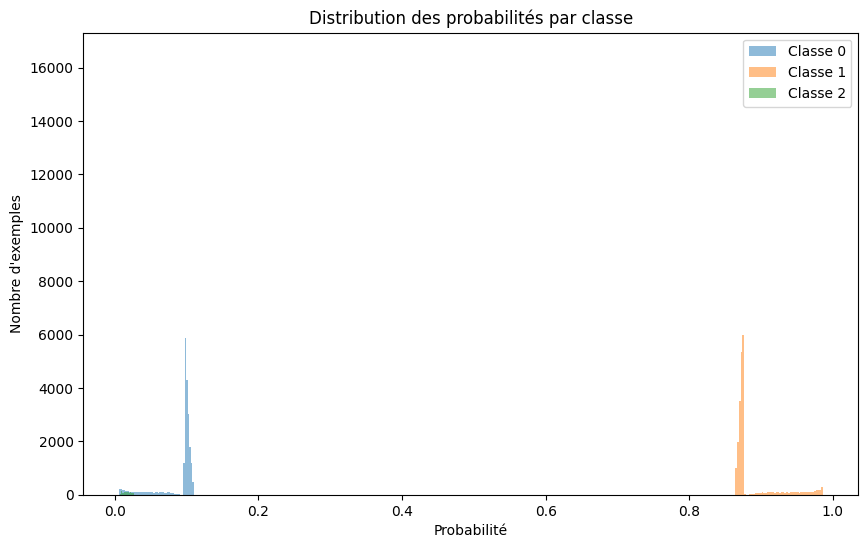

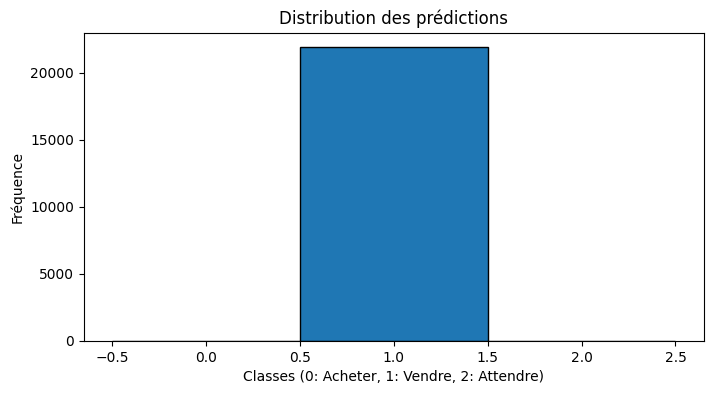

In [ ]:
# Évaluation des probabilités
model.eval()
with torch.no_grad():
    outputs = model(X_batch)
    probabilities = F.softmax(outputs, dim=1)
    avg_prob = probabilities.mean(dim=0)
    print("Probabilités moyennes par classe :", avg_prob.cpu().numpy())
    
    probs_np = probabilities.cpu().numpy()
    plt.figure(figsize=(10,6))
    for class_idx in range(probabilities.shape[1]):
        valid_probs = probs_np[:, class_idx][~np.isnan(probs_np[:, class_idx])]
        plt.hist(valid_probs, bins=50, alpha=0.5, label=f'Classe {class_idx}')
    plt.xlabel("Probabilité")
    plt.ylabel("Nombre d'exemples")
    plt.title("Distribution des probabilités par classe")
    plt.legend()
    plt.show()

with torch.no_grad():
    outputs = model(X_batch)
    _, preds = torch.max(outputs, 1)
    plt.figure(figsize=(8, 4))
    plt.hist(preds.numpy(), bins=np.arange(num_classes+1)-0.5, edgecolor='black')
    plt.xlabel("Classes (0: Acheter, 1: Vendre, 2: Attendre)")
    plt.ylabel("Fréquence")
    plt.title("Distribution des prédictions")
    plt.show()

In [ ]:
# Simulation de portefeuille basée sur les prédictions
initial_cash = 100000.0
cash = initial_cash
holding = False
shares = 0
portfolio_history = []
trade_details = []

for i in range(window_size, len(ticker_data)):
    signal = preds[i - window_size].item()  # 0: Acheter, 1: Vendre, 2: Attendre
    current_price = ticker_data.iloc[i]['Value']
    dt = ticker_data.index[i]
    
    if signal == 0:
        if not holding:
            allocation = 0.10 * cash
            shares = allocation / current_price
            cash -= shares * current_price
            holding = True
            trade_details.append({'Datetime': dt, 'Action': 'Buy', 'Price': current_price, 'Shares': shares})
    elif signal == 1:
        if holding:
            cash += shares * current_price
            trade_details.append({'Datetime': dt, 'Action': 'Sell', 'Price': current_price, 'Shares': shares})
            holding = False
            shares = 0
    
    portfolio_value = cash
    if holding:
        portfolio_value += shares * current_price
    portfolio_history.append((dt, portfolio_value))

portfolio_df = pd.DataFrame(portfolio_history, columns=['Datetime', 'PortfolioValue'])
portfolio_df.set_index('Datetime', inplace=True)
portfolio_df.sort_index(inplace=True)

print("Aperçu de l'évolution du portefeuille:")
print(portfolio_df.head())

Aperçu de l'évolution du portefeuille:
                           PortfolioValue
Datetime                                 
2023-03-13 10:00:00+00:00        100000.0
2023-03-13 10:00:00+00:00        100000.0
2023-03-13 11:00:00+00:00        100000.0
2023-03-13 11:00:00+00:00        100000.0
2023-03-13 11:00:00+00:00        100000.0


In [ ]:
portfolio_df['Return'] = portfolio_df['PortfolioValue'].pct_change()
total_return = (portfolio_df['PortfolioValue'].iloc[-1] / initial_cash) - 1
trading_hours_per_year = 252 * 6.5
num_hours = len(portfolio_df)
annualized_return = (portfolio_df['PortfolioValue'].iloc[-1] / initial_cash) ** (trading_hours_per_year / num_hours) - 1
volatility = portfolio_df['Return'].std()
cumulative_max = portfolio_df['PortfolioValue'].cummax()
drawdown = (portfolio_df['PortfolioValue'] - cumulative_max) / cumulative_max
max_drawdown = drawdown.min()
sharpe_ratio = portfolio_df['Return'].mean() / portfolio_df['Return'].std() * np.sqrt(trading_hours_per_year)
downside_returns = portfolio_df['Return'][portfolio_df['Return'] < 0]
downside_std = downside_returns.std()
sortino_ratio = portfolio_df['Return'].mean() / downside_std * np.sqrt(trading_hours_per_year)

print(f"Total Return: {total_return*100:.2f}%")
print(f"Annualized Return: {annualized_return*100:.2f}%")
print(f"Volatilité horaire: {volatility*100:.2f}%")
print(f"Maximum Drawdown: {max_drawdown*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")

Total Return: 0.00%
Annualized Return: 0.00%
Volatilité horaire: 0.00%
Maximum Drawdown: 0.00%
Sharpe Ratio: nan
Sortino Ratio: nan


C:\Users\thiba\AppData\Local\Temp\ipykernel_1924\4025115843.py:10: RuntimeWarning: invalid value encountered in scalar divide
  sharpe_ratio = portfolio_df['Return'].mean() / portfolio_df['Return'].std() * np.sqrt(trading_hours_per_year)


C:\Users\thiba\AppData\Local\Temp\ipykernel_1924\1655922511.py:17: RuntimeWarning: invalid value encountered in scalar divide
  sharpe_ratio = portfolio_df['Return'].mean() / portfolio_df['Return'].std() * np.sqrt(trading_hours_per_year)


Total Return: 0.00%
Annualized Return: 0.00%
Volatilité horaire: 0.00%
Maximum Drawdown: 0.00%
Sharpe Ratio: nan
Sortino Ratio: nan


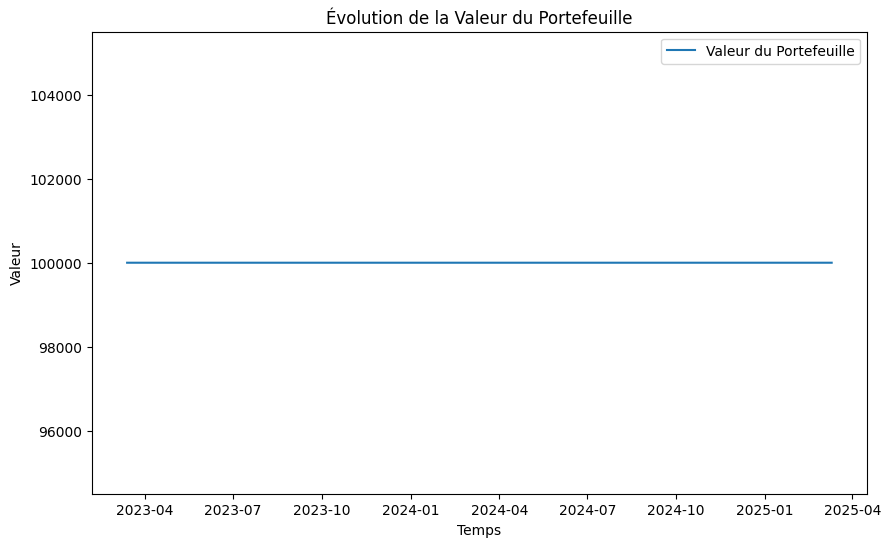

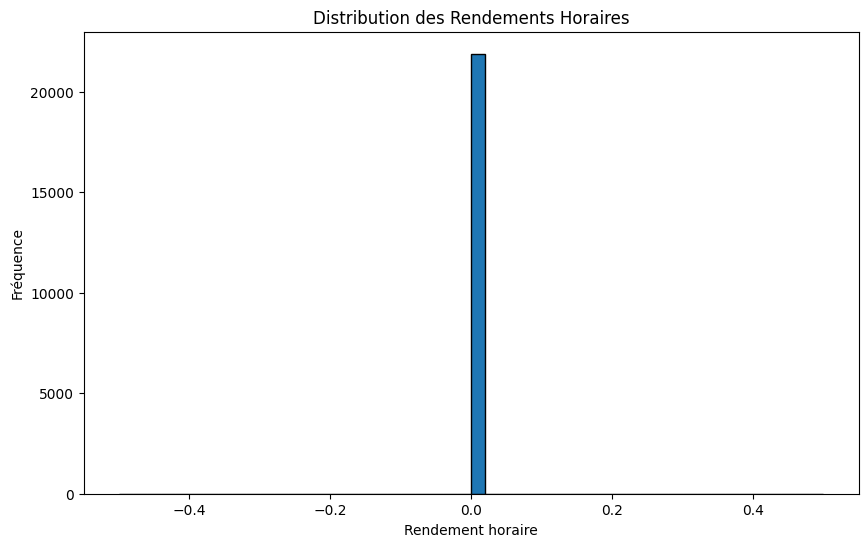

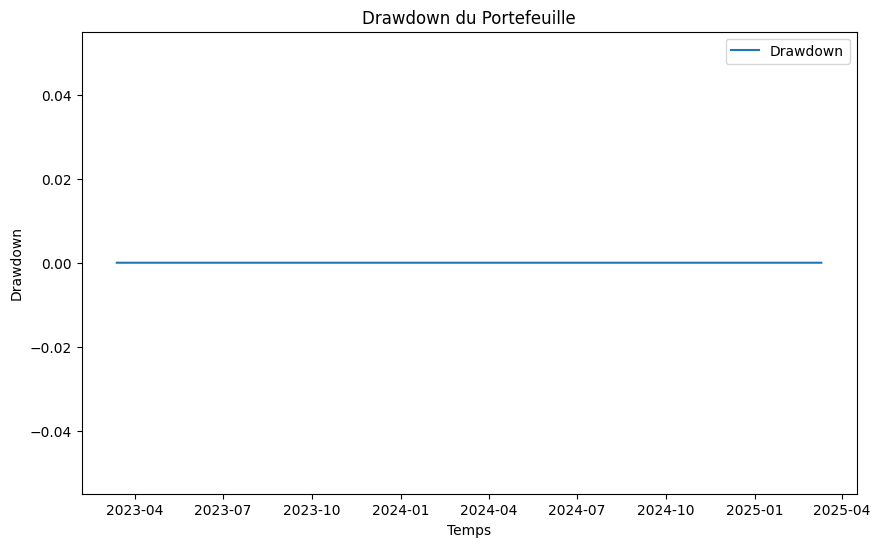

In [ ]:
# Calcul des métriques de performance
portfolio_df['Return'] = portfolio_df['PortfolioValue'].pct_change()
total_return = (portfolio_df['PortfolioValue'].iloc[-1] / initial_cash) - 1

# Estimation du nombre d'heures de trading par an (par exemple, 6.5 heures/jour, 252 jours/an)
trading_hours_per_year = 252 * 6.5
num_hours = len(portfolio_df)
annualized_return = (portfolio_df['PortfolioValue'].iloc[-1] / initial_cash) ** (trading_hours_per_year / num_hours) - 1
volatility = portfolio_df['Return'].std()

# Calcul du Maximum Drawdown
cumulative_max = portfolio_df['PortfolioValue'].cummax()
drawdown = (portfolio_df['PortfolioValue'] - cumulative_max) / cumulative_max
max_drawdown = drawdown.min()

# Ratio de Sharpe (en supposant un taux sans risque de 0)
sharpe_ratio = portfolio_df['Return'].mean() / portfolio_df['Return'].std() * np.sqrt(trading_hours_per_year)

# Ratio de Sortino (en ne considérant que les rendements négatifs)
downside_returns = portfolio_df['Return'][portfolio_df['Return'] < 0]
downside_std = downside_returns.std()
sortino_ratio = portfolio_df['Return'].mean() / downside_std * np.sqrt(trading_hours_per_year)

# Affichage des métriques
print(f"Total Return: {total_return*100:.2f}%")
print(f"Annualized Return: {annualized_return*100:.2f}%")
print(f"Volatilité horaire: {volatility*100:.2f}%")
print(f"Maximum Drawdown: {max_drawdown*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(portfolio_df.index, portfolio_df['PortfolioValue'], label='Valeur du Portefeuille')
plt.xlabel('Temps')
plt.ylabel('Valeur')
plt.title("Évolution de la Valeur du Portefeuille")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(portfolio_df['Return'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Rendement horaire')
plt.ylabel('Fréquence')
plt.title("Distribution des Rendements Horaires")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(portfolio_df.index, drawdown, label='Drawdown')
plt.xlabel('Temps')
plt.ylabel('Drawdown')
plt.title("Drawdown du Portefeuille")
plt.legend()
plt.show()
